In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [79]:
df = pd.read_csv("../../../data/processed/feature_dataset.csv")

In [80]:
# One hot encoding for age and recording location
df = pd.get_dummies(df, columns=["Age"], drop_first=True)

df = pd.get_dummies(df, columns=["recording_location"], drop_first=True)

df = pd.get_dummies(df, columns=["Murmur"], drop_first=True)

df["Sex"] = df["Sex"].map({
    "Female": 0,
    "Male": 1
})

df["Outcome"] = df["Outcome"].map({
    "Normal": 0,
    "Abnormal": 1
})

In [81]:
# -----------------------------
# Split using your predefined split
# -----------------------------
train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

In [82]:
# -----------------------------
# Prepare features
# -----------------------------
drop_cols = ["Patient ID", "Outcome", "split", "file", "Campaign", "Additional ID", "Height", "Weight"]

drop_cols = drop_cols + ["rms"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Outcome"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["Outcome"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["Outcome"]

In [83]:
# Calculate correlation matrix
corr_matrix = X_train.corr()

# Get upper triangle only (avoid duplicate pairs and self-correlation)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated feature pairs
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "Feature 1",
        "level_1": "Feature 2",
        0: "Correlation"
    })
)

# Sort by absolute correlation
high_corr["Abs Correlation"] = high_corr["Correlation"].abs()

high_corr = high_corr.sort_values(
    by="Abs Correlation",
    ascending=False
)

# Show correlations above threshold
threshold = 0.9

print(
    high_corr[
        high_corr["Abs Correlation"] >= threshold
    ]
)

               Feature 1          Feature 2  Correlation  Abs Correlation
1072   spectral_centroid   spectral_rolloff     0.960905         0.960905
1191  spectral_bandwidth        mfcc_2_mean    -0.954890         0.954890
9204         mfcc_12_std     mfcc_d1_12_std     0.949410         0.949410
9846         mfcc_13_std     mfcc_d1_13_std     0.949144         0.949144
8562         mfcc_11_std     mfcc_d1_11_std     0.947708         0.947708
7920         mfcc_10_std     mfcc_d1_10_std     0.943340         0.943340
7278          mfcc_9_std      mfcc_d1_9_std     0.943027         0.943027
1073   spectral_centroid  spectral_flatness     0.937764         0.937764
1178  spectral_bandwidth   spectral_rolloff     0.933680         0.933680
6636          mfcc_8_std      mfcc_d1_8_std     0.925447         0.925447
9206         mfcc_12_std     mfcc_d2_12_std     0.924024         0.924024
7280          mfcc_9_std      mfcc_d2_9_std     0.923959         0.923959
8564         mfcc_11_std     mfcc_d2_1

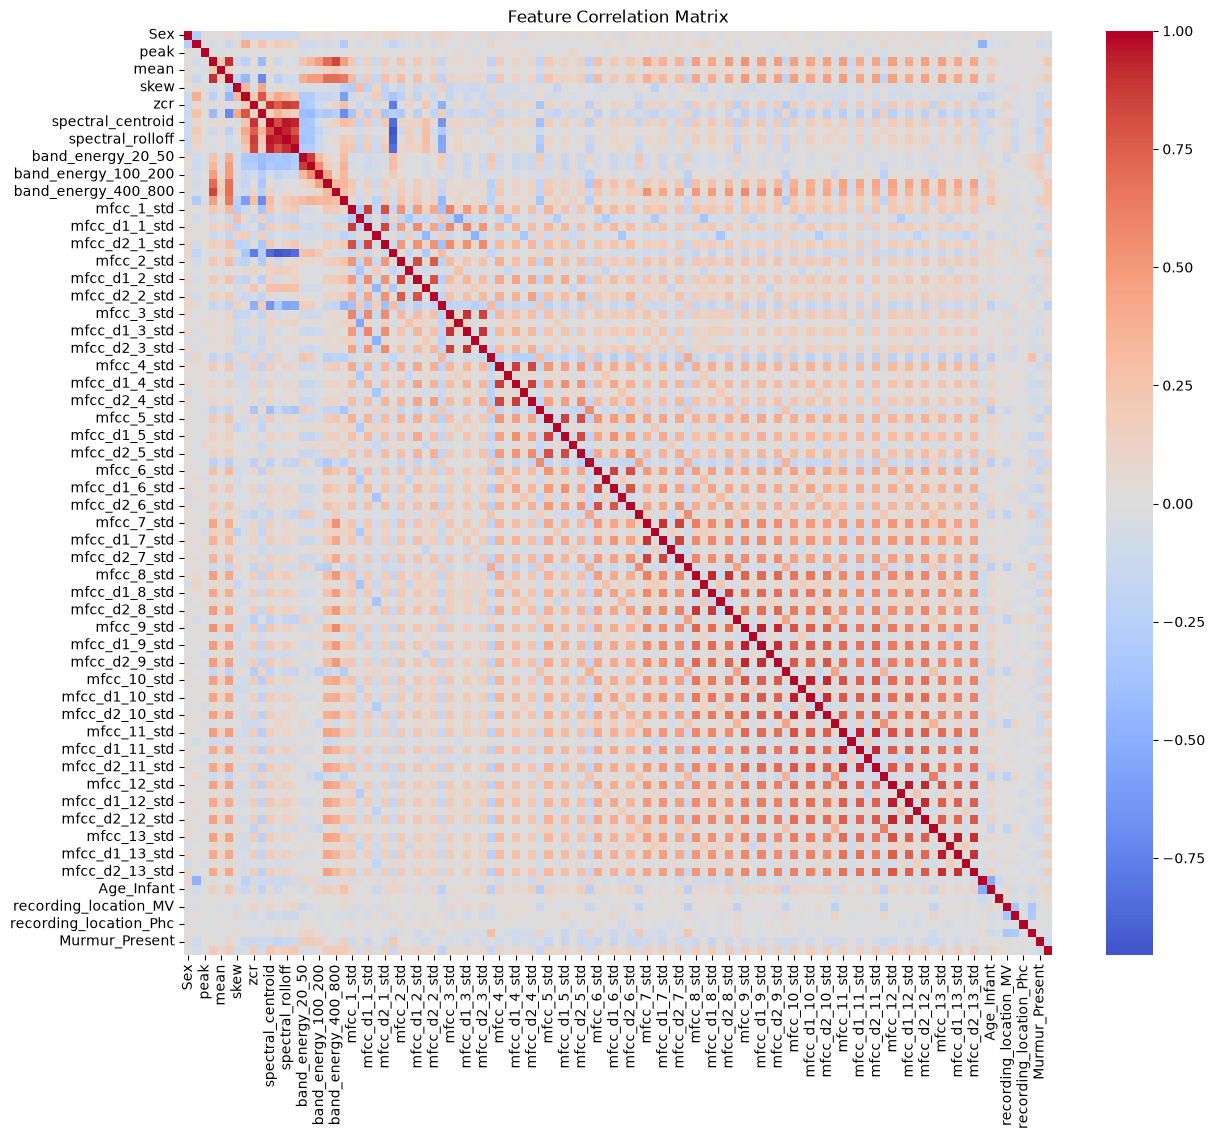

In [65]:
# Plot heatmap of correlation matrix

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [84]:
# -----------------------------
# Scaling (IMPORTANT for linear models)
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [85]:
# -----------------------------
# Models
# -----------------------------
models = {
    "L2": LogisticRegression(
        penalty="l2",
        C=0.1,
        max_iter=4000
    ),

    "L1": LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.1,
        max_iter=4000
    ),

    "ElasticNet": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=0.1,
        l1_ratio=0.5,
        max_iter=4000
    )
}

# Feature names after dropping unwanted columns
train_df_dropped = train_df.drop(columns=drop_cols)

# Store results
coefficients = {}

# Train and analyze models
for name, model in models.items():
    model.fit(X_train, y_train)

    coef = pd.Series(
        model.coef_[0],
        index=train_df_dropped.columns
    )

    coefficients[name] = coef

c:\Users\malek\Desktop\Malek\Studium\M.Sc Informatik (TUM)\Semester 2\(CaCOM)\CaCOM-HeartWISE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\malek\Desktop\Malek\Studium\M.Sc Informatik (TUM)\Semester 2\(CaCOM)\CaCOM-HeartWISE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 

In [86]:
# Features selected by each model
for name, coef in coefficients.items():
    print(f"\n{name} selected features:")
    print(coef[coef != 0].sort_values(key=abs, ascending=False))


L2 selected features:
Murmur_Present         0.787996
mfcc_1_std             0.301944
Pregnancy status      -0.298852
mfcc_d2_9_std         -0.264244
band_energy_100_200    0.239824
                         ...   
mfcc_d2_7_mean         0.006535
mfcc_d1_7_mean         0.006065
mfcc_d1_8_mean         0.004945
mfcc_d2_3_mean         0.002830
mfcc_13_mean           0.002474
Length: 106, dtype: float64

L1 selected features:
Murmur_Present            0.761827
Pregnancy status         -0.263596
Murmur_Unknown            0.118906
mfcc_8_mean              -0.115144
mfcc_d2_1_std            -0.107604
mfcc_12_mean              0.101139
mfcc_d2_1_mean           -0.100976
band_energy_100_200       0.100405
mfcc_7_mean              -0.098670
mfcc_d2_9_std            -0.088887
recording_location_Phc    0.082506
mfcc_3_mean              -0.079856
mfcc_d1_12_mean           0.077680
mfcc_d2_2_mean           -0.063716
mfcc_d1_11_std           -0.063663
mfcc_d2_2_std             0.062961
mfcc_8_std    

In [87]:
summary = pd.DataFrame({
    name: {
        "selected_features": (coef != 0).sum(),
        "zero_coefficients": (coef == 0).sum()
    }
    for name, coef in coefficients.items()
}).T

print(summary)

            selected_features  zero_coefficients
L2                        106                  0
L1                         53                 53
ElasticNet                 74                 32


In [89]:
results = []

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Coefficients
    coef = pd.Series(
        model.coef_[0],
        index=train_df_dropped.columns
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Features": (coef != 0).sum()
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("ROC-AUC", ascending=False))

        Model  Accuracy  Precision    Recall        F1   ROC-AUC  Features
0          L2  0.670886   0.731429  0.540084  0.621359  0.703591       106
1          L1  0.668776   0.753165  0.502110  0.602532  0.698072        53
2  ElasticNet  0.662447   0.730539  0.514768  0.603960  0.697965        74


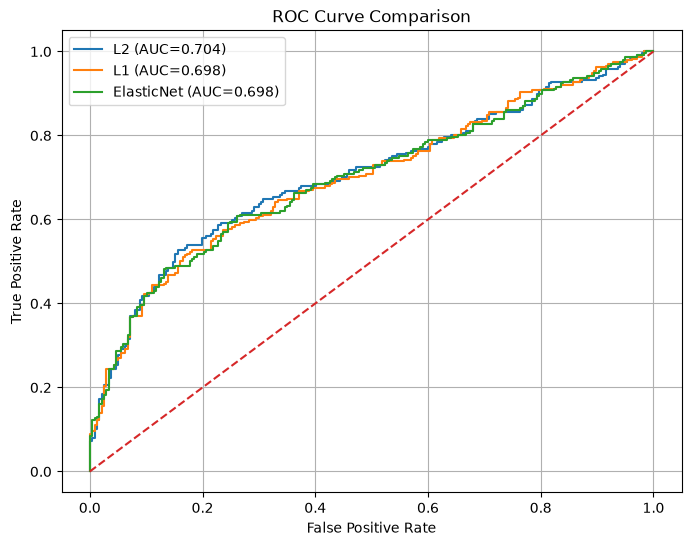

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()